In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json, re, os
from tqdm.auto import tqdm


In [ ]:
# We will get a list of title from markdown links
from collections import defaultdict
import re
titles_md = defaultdict(list)


title_blocklist = ['patreon', 'here', 'link', 'this', 'delete', 'this one', 'vote', 'image', 'comic explanation', 'this link', 'this thread', 'redact', '(link)', 'this post', 'CLICK THIS LINK', "here's", 'wiki', 'report', 'source', 'the wiki', 'reddit - dive into anything', 'top posts', 'a patreon campaign', 'table of contents', 'fanfiction.net', 'this video', 'here.']
                   

def remember_md_link_titles(markdown_text):
    # Regular expression to match markdown links
    markdown_link_pattern = re.compile(r'\[([^\]]+)\]\((http[s]?://[^\)]+)\)')

    # Find all markdown links
    for match in markdown_link_pattern.findall(markdown_text):
        title, url = match
        # tidy title of * / _ and remove leading/trailing whitespace
        title = title.strip().strip('*').strip('_')

        if len(title)<3:
            continue

        if title.startswith('http'):
            continue
        if title.startswith('^'):
            continue

        if title.lower() in title_blocklist:
            continue


        titles_md[url].append(title)



In [3]:
fs = sorted(Path('../data/json2').glob('*.json'))
len(fs)

10257

In [26]:

def extract_links_re(s:str):
    return re.findall(r'\[.*?\]\((.*?)\)', s)



from collections import defaultdict
karma = defaultdict(int) # track score
gossip = defaultdict(list) # track number and content of comments... FIXME should include subcomments?
gossip_threads = defaultdict(list)
dates = defaultdict(list)

banned_suffixes = ['jpeg', 'png', 'jpg']

data = []
for f in fs:
    s = json.loads(f.open().read())

    for comment in s['comments']:
        text = comment['body']
        links = extract_links_re(text)
        links = [l for l in links if not any(l.endswith(s) for s in banned_suffixes)]
        remember_md_link_titles(text)
        for l in links:
            karma[l] += comment['score'] / len(links)
            gossip[l].append(comment['body'])
            gossip_threads[l].append('https://reddit.com' + comment['permalink'])
            dates[l].append(s['created_utc'])
        data += links

len(data)

45067

In [5]:
# data

In [6]:
len(titles_md)

25797

In [7]:
# QC top links
pd.Series(karma).sort_values(ascending=False).head(50)

https://www.patreon.com/alexanderwales                                                                                  880.000000
https://redact.dev/home                                                                                                 422.000000
https://archiveofourown.org/works/11478249/chapters/25740126                                                            328.040476
https://www.fanfiction.net/s/10360716/1/The-Metropolitan-Man                                                            300.614797
https://archiveofourown.org/works/6178036/chapters/14154868                                                             291.982143
http://topwebfiction.com/vote.php?for=a-practical-guide-to-evil                                                         257.333333
https://twigserial.wordpress.com/                                                                                       244.894859
https://docs.google.com/spreadsheets/d/1PaLrwVYgxp_SYHtkred7ybpSJPHL88lf4zB0zMKmk1E

In [8]:
df_links = pd.Series(data).value_counts()
df_links.shape

(32085,)

In [9]:
blocklist = [
#   'reddit',
    'redact', 'pastebin', 'wikipedia', 'docs.google', 'discord','tvtropes.org', 'ask_wikibot', 'autowiki', 'banned',
    # pateron.com ?
    'reddit.com/user/', 'xkcd', 'ebay', 'youtubot',
    'reddit.com/r/rational',
    # 'sneakpeekbot', 'RemindMeBot', 
    # 'WikiSummarizerBot', 'bot/', 'Bot/',
    'knowyourmeme.com', 'UserSim',
    'vote.php',
    ]


allowlist = ['hfy']
df_links = df_links[~df_links.index.str.contains('|'.join(blocklist), regex=True) | df_links.index.str.contains('|'.join(allowlist), regex=True)]
df_links = df_links[df_links.index.str.startswith('http')]
df_links = df_links[df_links > 1]

# if it has reddit and bot in the title, it's probably a bot
df_links = df_links[~(df_links.index.str.contains('reddit', case=False) & df_links.index.str.contains('bot', case=False))]

# QC
pd.Series(df_links.index, index=df_links.values)

63    https://archiveofourown.org/works/11478249/cha...
61                 https://www.fanfiction.net/s/5193644
60    https://www.fictionpress.com/s/2961893/1/Mothe...
55    https://www.fanfiction.net/s/10360716/1/The-Me...
48                    https://twigserial.wordpress.com/
                            ...                        
2     https://www.fimfiction.net/story/132779/onto-t...
2     https://archiveofourown.org/works/22022296/cha...
2                            http://craphound.com/down/
2     http://www.youngwizards.com/ErrantryWiki/index...
2     https://forums.sufficientvelocity.com/threads/...
Length: 3129, dtype: object

<Axes: ylabel='Frequency'>

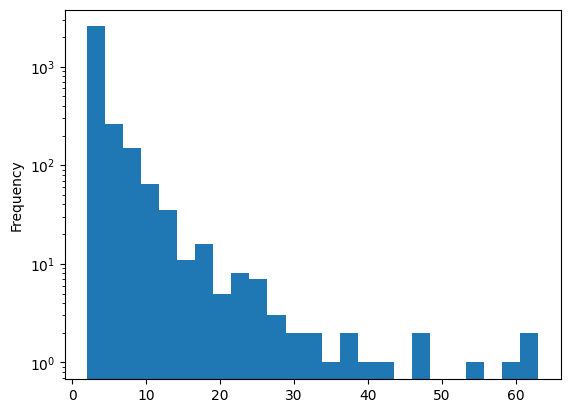

In [10]:
df_links.plot.hist(bins=25, logy=True)

In [11]:
# df_links.to_markdown('../outputs/links2.md')

# Get title

This is hard as it's an adverserial web scraping problem, I'll use a mix of methods (from the markdown, requests, url)

In [12]:
from anycache import anycache
f_cache = Path('../outputs/.anycache')

In [ ]:
# #DEBUG clear
# import shutil
# shutil.rmtree(f_cache)

In [14]:
# dedup using title

from pathlib import Path
from bs4 import BeautifulSoup
import cloudscraper


session = cloudscraper.create_scraper()


def get_title_md(url):
    if url in titles_md:
        s = pd.Series(titles_md[url])
        return s.value_counts().index[0] # return most common title
    return url

@anycache(f_cache)
def get_title(url):
    # first check if it's in the cache
    if url in titles_md:
        return get_title_md(url)

    # try scraping from the web
    try:
        r = session.get(url, timeout=5, allow_redirects=True)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        title = soup.title.text.strip()
        return title
    except Exception as e:

        # if that doesn't work, does the end of the url contain a slugged title?
        # e.g. https://www.fanfiction.net/s/5193644/harry-potter-and-the-methods-of-rationality
        slugged_title = url.split('/')[-1].replace('-', ' ')
        if ' ' in slugged_title:
            return slugged_title
    
        raise e  

# url = df_links.index[0]
# r = get_title(url)
# url, r


In [15]:
data2 = []
for i in tqdm(range(len(df_links))):
    urls = df_links.index[i]
    try:
        title = get_title(urls)
    except Exception as e:
        print(f'failed to get title for {urls}: {e}')
        title = urls
    comments = gossip[urls]
    score = karma[urls]
    comment_urls = gossip_threads[urls]
    num_comments = len(comments)
    created_utc = dates[urls]
    data2.append(dict(url=urls, title=title, score=score, comments=comments, num_comments=num_comments, comment_urls=comment_urls, dates=created_utc))

df2 = pd.DataFrame(data2)
df2

  0%|          | 0/3129 [00:00<?, ?it/s]

failed to get title for http://delphicserial.com/2017/10/21/ch01/: HTTPConnectionPool(host='delphicserial.com', port=80): Max retries exceeded with url: /2017/10/21/ch01/ (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x782dce8be560>: Failed to resolve 'delphicserial.com' ([Errno -2] Name or service not known)"))
failed to get title for http://github.com/lizardsrock4: 404 Client Error: Not Found for url: https://github.com/lizardsrock4
failed to get title for https://np.reddit.com/r/OutOfTheLoop/comments/3fbrg3/is_there_a_reason_why_the_arm_is_always_missing/ctn5gbf/: 429 Client Error: Too Many Requests for url: https://np.reddit.com/r/OutOfTheLoop/comments/3fbrg3/is_there_a_reason_why_the_arm_is_always_missing/ctn5gbf/
failed to get title for https://www.fictionpress.com/s/3198066/1/Fimbulwinter: 403 Client Error: Forbidden for url: https://www.fictionpress.com/s/3198066/1/Fimbulwinter
failed to get title for https://www.fanfiction.net/s/10263221: 403 Cli

,url,title,score,comments,num_comments,comment_urls,dates
0,https://archiveofourown.org/works/11478249/cha...,Worth the Candle,328.040476,[>>interestingly blend ...\n\n>`[g]`enres\n\n>...,63,[https://reddit.com/r/rational/comments/1c4mxk...,"[1713189611.0, 1503163699.0, 1506215679.0, 150..."
1,https://www.fanfiction.net/s/5193644,Time Braid,116.619421,[* [*Waves Arisen*](https://wertifloke.wordpre...,61,[https://reddit.com/r/rational/comments/11wjn0...,"[1679320813.0, 1682949618.0, 1429816392.0, 143..."
2,https://www.fictionpress.com/s/2961893/1/Mothe...,Mother of Learning,209.998729,[And [Mother of Learning](https://www.fictionp...,60,[https://reddit.com/r/rational/comments/2br02d...,"[1406342508.0, 1417735601.0, 1418670015.0, 141..."
3,https://www.fanfiction.net/s/10360716/1/The-Me...,The Metropolitan Man,300.614797,"[~ [*Death Note: L, Anonymity & Eluding Entrop...",55,[https://reddit.com/r/rational/comments/134n9q...,"[1682949618.0, 1687788016.0, 1400177222.0, 140..."
4,https://twigserial.wordpress.com/,Twig,244.894859,[The protagonist of [Twig](https://twigserial....,48,[https://reddit.com/r/rational/comments/17ucgu...,"[1699887610.0, 1725890413.0, 1450408569.0, 147..."
...,...,...,...,...,...,...,...
3124,https://www.fimfiction.net/story/132779/onto-t...,Onto the Pony Planet,0.666667,"[So these aren't quite uplifty, for various re...",2,[https://reddit.com/r/rational/comments/a4a9ys...,"[1544271356.0, 1568646297.0]"
3125,https://archiveofourown.org/works/22022296/cha...,Blood Crest,16.333333,[[Blood Crest](https://archiveofourown.org/wor...,2,[https://reddit.com/r/rational/comments/u6dueo...,"[1650290410.0, 1651500009.0]"
3126,http://craphound.com/down/,"link to the author's site, where CC-licensed d...",10.666667,"[[link to the author's site, where CC-licensed...",2,[https://reddit.com/r/rational/comments/23tdjs...,"[1398298405.0, 1410439827.0]"
3127,http://www.youngwizards.com/ErrantryWiki/index...,Lone Power,5.833333,[Alternate Character Interpretations are one t...,2,[https://reddit.com/r/rational/comments/3j2pty...,"[1441022185.0, 1467990282.0]"


In [16]:
# QC: get top markdown titles
import itertools
l = sorted(itertools.chain(*titles_md.values()))
pd.Series(l).value_counts().head(50)

Vote for A Practical Guide to Evil on TopWebFiction!                102
Time Braid                                                           94
Mother of Learning                                                   66
Worm                                                                 66
Worth the Candle                                                     64
Twig                                                                 59
on the #pokengineering channel of the /r/rational Discord server     57
Handy discussion links and previous threads here                     54
Stop Replying                                                        52
Statistics                                                           52
Problems/Bugs?                                                       52
xkcd.com                                                             52
xkcd sub                                                             52
top posts                                                       

In [17]:
# join by title

def join_uniq(x:list[str]):
    return '\n'.join(set(x))

def chain_lists(x:list[list[str]]):
    return [item for sublist in x for item in sublist]

df3 = df2.groupby('title').agg({'score': 'sum', 'num_comments': 'sum', 'comments': chain_lists, 'url': join_uniq, 'comment_urls': chain_lists, 'dates': chain_lists
                                }).sort_values('score', ascending=False)
df3.head(33)

,score,num_comments,comments,url,comment_urls,dates
title,,,,,,
a Patreon campaign,880.000000,22,[I do have a subreddit set up for this over at...,https://www.patreon.com/alexanderwales,[https://reddit.com/r/rational/comments/331re9...,"[1429380255.0, 1432400450.0, 1436482846.0, 146..."
Worth the Candle,661.062143,108,[>>interestingly blend ...\n\n>`[g]`enres\n\n>...,https://archiveofourown.org/works/11478249/cha...,[https://reddit.com/r/rational/comments/1c4mxk...,"[1713189611.0, 1503163699.0, 1506215679.0, 150..."
Worm,414.596255,78,[[Kitty Cat Kill Sat](https://www.royalroad.co...,https://parahumans.wordpress.com\nhttps://para...,[https://reddit.com/r/rational/comments/16rsx5...,"[1695650418.0, 1699887610.0, 1706540412.0, 171..."
Twig,346.983574,63,[The protagonist of [Twig](https://twigserial....,https://twigserial.wordpress.com/about/\nhttps...,[https://reddit.com/r/rational/comments/17ucgu...,"[1699887610.0, 1725890413.0, 1450408569.0, 147..."
With This Ring,329.593551,59,[> puts out more chapters faster than any web ...,https://forums.sufficientvelocity.com/threads/...,[https://reddit.com/r/rational/comments/52bbjb...,"[1473635989.0, 1481638770.0, 1514051962.0, 152..."
The Metropolitan Man,319.948130,57,"[~ [*Death Note: L, Anonymity & Eluding Entrop...",https://alexanderwales.com/the-metropolitan-ma...,[https://reddit.com/r/rational/comments/134n9q...,"[1682949618.0, 1687788016.0, 1400177222.0, 140..."
Cordyceps,311.815476,41,"[If you like that, be sure to read [CORDYCEPS]...",http://archiveofourown.org/works/6178036/chapt...,[https://reddit.com/r/rational/comments/1eqehs...,"[1723471212.0, 1504188940.0, 1504579227.0, 150..."
Mother of Learning,303.770050,83,[And [Mother of Learning](https://www.fictionp...,https://www.royalroad.com/fiction/21220/mother...,[https://reddit.com/r/rational/comments/2br02d...,"[1406342508.0, 1417735601.0, 1418670015.0, 141..."
Time Braid,280.345557,99,[* [*Waves Arisen*](https://wertifloke.wordpre...,https://www.fanfiction.net/s/5193644\nhttps://...,[https://reddit.com/r/rational/comments/11wjn0...,"[1679320813.0, 1682949618.0, 1429816392.0, 143..."


In [18]:
df2.shape, df3.shape

((3129, 7), (2743, 6))

In [19]:
# df3.to_markdown('../outputs/links3.md')

### Export to html

In [25]:
import jinja2
environment = jinja2.Environment()
template = open('../index.jinja2.html').read()
template = environment.from_string(template)
d = (df3
     .reset_index()
     .sort_values('score', ascending=False)
    )

def url2a(url):
    text = url
    if 'reddit.com/r/rational' in url:
        text = url.split('/')[-2]
        # text = url.replace('https://reddit.com/r/rational/comments/', '')

    return f'<a href="{url}">{text}</a>'

def urls2a(urls, sep='<br>'):
    if isinstance(urls, str):
        urls = urls.split('\n')
    
    return sep.join(url2a(u) for u in urls)
d['url'] = d['url'].apply(urls2a)
d['score'] = d['score'].round(2)
d['comment_urls'] = d['comment_urls'].apply(lambda s:urls2a(s, sep=' '))

# TODO comment md to html... if I want to keep them

def get_first_date(x):
    return pd.to_datetime(x, unit='s').min().strftime('%Y-%m-%d %H:%M:%S')
d['dates'] = d['dates'].apply(get_first_date)

data = d.to_json(orient='values')

hidden = ['comments', 'comment_urls']
columns=[{
    'title':c, 
    'visible': c not in hidden,
    'searchable': c not in hidden,
    } for c in d.columns]
columns = json.dumps(columns)


html = template.render(data=data,
                       columns=columns,
                       )
html_out = Path('../outputs/index.html').resolve()
open(html_out, 'w').write(html)
columns

'[{"title": "title", "visible": true, "searchable": true}, {"title": "score", "visible": true, "searchable": true}, {"title": "num_comments", "visible": true, "searchable": true}, {"title": "comments", "visible": false, "searchable": false}, {"title": "url", "visible": true, "searchable": true}, {"title": "comment_urls", "visible": false, "searchable": false}, {"title": "dates", "visible": true, "searchable": true}]'

In [21]:
from IPython.display import display, HTML
htmla = f'<a href="{html_out}">View the page {html_out}</a>'
display(HTML(htmla))

In [22]:
# df3.to_html('../outputs/links3.html')

## Extra get a llm summary of each link

Grab all md's that mention a story, ask claude to summarize

We could also get total karma per mention

In [23]:
import os
import dotenv
dotenv.load_dotenv()
from openai import OpenAI
client = OpenAI()

import tiktoken
enc = tiktoken.encoding_for_model("gpt-4o-mini")
cost = 0.150 / 1e6

ModuleNotFoundError: No module named 'sniffio'

In [ ]:
posts = []
fs = sorted(Path('../data/cache2').glob('*.md'))
for f in fs:
    s = f.open().read()
    posts.append(s)


def get_post_context(urls:List[str], budget = 100000):
    # FIXME take in multiple urls and titles
    # FIXME given a token or char budget
    assert len(title)>0
    # from comments
    # return df3.loc[title].comments

    # or I could just all markdowns with

    # TODO use langchain chunking?

    matches = []
    for ii, post in enumerate(posts):
        for url in urls:
            if url in post:
                matches.append(post)
                break
    
    budget_pp = budget / len(matches)
    s = ''
    for i in range(len(matches)):

        post = matches[i]

        for url in urls:
            if url in post:
                ind = post.index(url)
        
        i0 = int(max(0, ind-budget_pp//4))
        i1 = int(min(len(post), ind+budget_pp//4*3))
        post_chunk = post[i0:i1]
        if i0>0:
            post_chunk = '...' + post_chunk
        if i1<len(post):
            post_chunk = post_chunk + '...'
                
        s += (f'\n\n----- Thread {ii} -----\n\n' + post_chunk)
    return s

# url = df3.url[0].split('\n')
# print(url)
# c = get_context(url, 400000)
# print(c[:1000])

In [ ]:


from pydantic import BaseModel, Field
from typing import List, Optional, Dict

class FictionInfo(BaseModel):
    name: str
    description: str
    tags: List[str]
    rating: Optional[float] = Field(description='Your own impression of the user sentiment as a rating out of 10.')
    sentiment: Optional[str]
    reviews: List[str] = Field(description='Directly quote any reviews and attribute the username if known')
    reccomendation_summary: str = Field(description='tldr why users recommend (if they do).')
    disreccomendation_summary: str = Field(description='Brief summary of why users disrecommend it to other r/rational readers (if they do).')

f_cache = Path('../outputs/.anycache3')
# @anycache(f_cache)
def get_llm_summary(name:str, context:str):
    chat_completion = client.beta.chat.completions.parse(
        messages=[
            {"role": "system", "content": "You are Gwern Branwern, an internet librarian who specializes in rational fiction. You are summarising community reccomendations into a structured form."},
            {
                "role": "user",
                "content": f"""For u/gwern please summarize information about {name}. Quote users and attribute the username if known.

### Context:

{context}"""
            }
        ],
        model="gpt-4o-mini",
        response_format=FictionInfo,
    )
    
    return chat_completion.choices[0].message.parsed.__dict__

In [ ]:
from IPython.display import display


In [ ]:
df4 = df3.copy()
df4['description'] = ''
df4['tags'] = None
df4['rating'] = None
df4['sentiment'] = None
df4['reviews'] = None


l = min(100, len(df4))
for i in tqdm(range(1, l)):
    title = df4.index[i]
    urls = df4.url[i]

    context = get_post_context(urls)
    tokens = len(enc.encode(context))
    print(f"Input Tokens: {tokens}. Input Cost: {cost * tokens:.4f} USD, for url {urls}")

    llm_data = get_llm_summary(urls, context)

    # print(f"Content: {context}")
    # print(url, d)
    display(llm_data)

    # add the fields to the dataframe rows
    df4.loc[urls, 'description'] = llm_data['description']
    df4.loc[urls, 'tags'] = ','.join(llm_data['tags'])
    df4.loc[urls, 'rating'] = llm_data['rating']
    df4.loc[urls, 'sentiment'] = llm_data['sentiment']
    df4.loc[urls, 'reviews'] = ','.join(llm_data['reviews'])
    df4.loc[urls, 'name'] = llm_data['name']
    df4.loc[urls, 'reccomendation_summary'] = llm_data['reccomendation_summary']
    df4.loc[urls, 'disreccomendation_summary'] = llm_data['disreccomendation_summary']
    1/0

In [ ]:
urls